# 01 · Unified Dataset Construction and Analysis

Builds the merged 256-class corpus from RAS-Compound, Ekush and MatriVasha, and reproduces
every dataset number quoted in the paper (Section 3.2) along with Figures 2, 4 and 5.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
from collections import Counter, defaultdict
import statistics
from train_merged import build_manifest, stratified_split, load_mapping, ROOT, DATA
print('project root:', ROOT)

project root: /Users/uthsob/reasearch/bornomal-pm


## Label reconciliation

Each corpus indexes classes by a local folder number whose meaning is defined only by that
project's own mapping file. We resolve every folder to its Bengali grapheme, NFC-normalise,
and take the union — so the same character from different corpora collapses to one label.

In [2]:
ras   = load_mapping(ROOT/'ras_class_mapping.csv', 'class_id', 'bengali_character')
ekush = load_mapping(DATA/'ekush-dataset'/'metaData_img.csv', 'Folder Name', 'Char Name')
matri = load_mapping(ROOT/'matrivasha_mapping.csv', 'folder', 'character')

R, E, M = set(ras.values()), set(ekush.values()), set(matri.values())
print(f'RAS-Compound : {len(R)} classes')
print(f'Ekush        : {len(E)} classes')
print(f'MatriVasha   : {len(M)} classes')
print(f'Union        : {len(R|E|M)} classes')

RAS-Compound : 119 classes
Ekush        : 122 classes
MatriVasha   : 115 classes
Union        : 256 classes


In [3]:
print('Pairwise overlap')
print(f'  RAS  n Ekush : {len(R&E)}')
print(f'  RAS  n Matri : {len(R&M)}')
print(f'  Ekush n Matri: {len(E&M)}')
print(f'  all three    : {len(R&E&M)}')
print()
print('Contributed by exactly one source')
print(f'  RAS only     : {len(R-E-M)}')
print(f'  Ekush only   : {len(E-R-M)}')
print(f'  Matri only   : {len(M-R-E)}')
print(f'  total unique : {len(R-E-M) + len(E-R-M) + len(M-R-E)} of {len(R|E|M)}')

Pairwise overlap
  RAS  n Ekush : 37
  RAS  n Matri : 58
  Ekush n Matri: 8
  all three    : 3

Contributed by exactly one source
  RAS only     : 27
  Ekush only   : 80
  Matri only   : 52
  total unique : 159 of 256


## Manifest and per-source composition (Table 1)

In [4]:
samples, classes = build_manifest()
src = Counter('RAS-Compound' if 'RAS-Comp' in p else
              'Ekush' if 'ekush' in p else 'MatriVasha' for p, _ in samples)
for name, n in src.most_common():
    print(f'{name:14s} {n:>7,} images')
print(f'{"TOTAL":14s} {len(samples):>7,} images across {len(classes)} classes')

Ekush          367,018 images
MatriVasha     306,461 images
RAS-Compound     7,830 images
TOTAL          681,309 images across 256 classes


## Class imbalance

The distribution is **not** Zipfian but sharply bimodal: a broad flat body, then a cliff to a
27-class rare tail contributed entirely by RAS-Compound.

In [5]:
counts = Counter(l for _, l in samples)
v = sorted(counts.values())
print(f'min {v[0]}  max {v[-1]}  median {statistics.median(v):.0f}  mean {statistics.mean(v):.0f}')
print(f'classes with <100 samples: {sum(1 for x in v if x < 100)}')
print(f'classes with <500 samples: {sum(1 for x in v if x < 500)}')

rare = [classes[c] for c, n in counts.items() if n < 100]
print(f'\nrare classes ({len(rare)}): ' + ' '.join(rare))

min 59  max 5740  median 2636  mean 2661
classes with <100 samples: 27
classes with <500 samples: 27

rare classes (27): ক্ন ক্য ক্ষ্ণ খ্র গ্য ঘ্র জ্য ঞ্ছ ণ্ট ণ্ড ণ্ম ত্য ত্ল দ্য ধ্য ধ্র ন্য ন্র ন্স প্ব প্ম প্য ফ্র ব্য ব্র ম্য ল্য


## Splits — identical for every architecture (seed 42)

In [6]:
for name, lim in [('Full corpus', None), ('Equal budget (300/class)', 300)]:
    tr, va, te = stratified_split(samples, limit_per_class=lim)
    print(f'{name:26s} train {len(tr):>7,} | val {len(va):>6,} | test {len(te):>6,}')

Full corpus                train 545,289 | val 68,010 | test 68,010


Equal budget (300/class)   train  56,414 | val  7,035 | test  7,035

## Figures 2, 4 and 5

In [7]:
sys.path.insert(0, os.path.abspath('../paper'))
from figures import fig2_dataset, fig4_samples, fig5_preprocessing
for fn in (fig2_dataset, fig4_samples, fig5_preprocessing):
    fn(); print(fn.__name__, 'written')

fig2_dataset written


fig4_samples written


fig5_preprocessing written


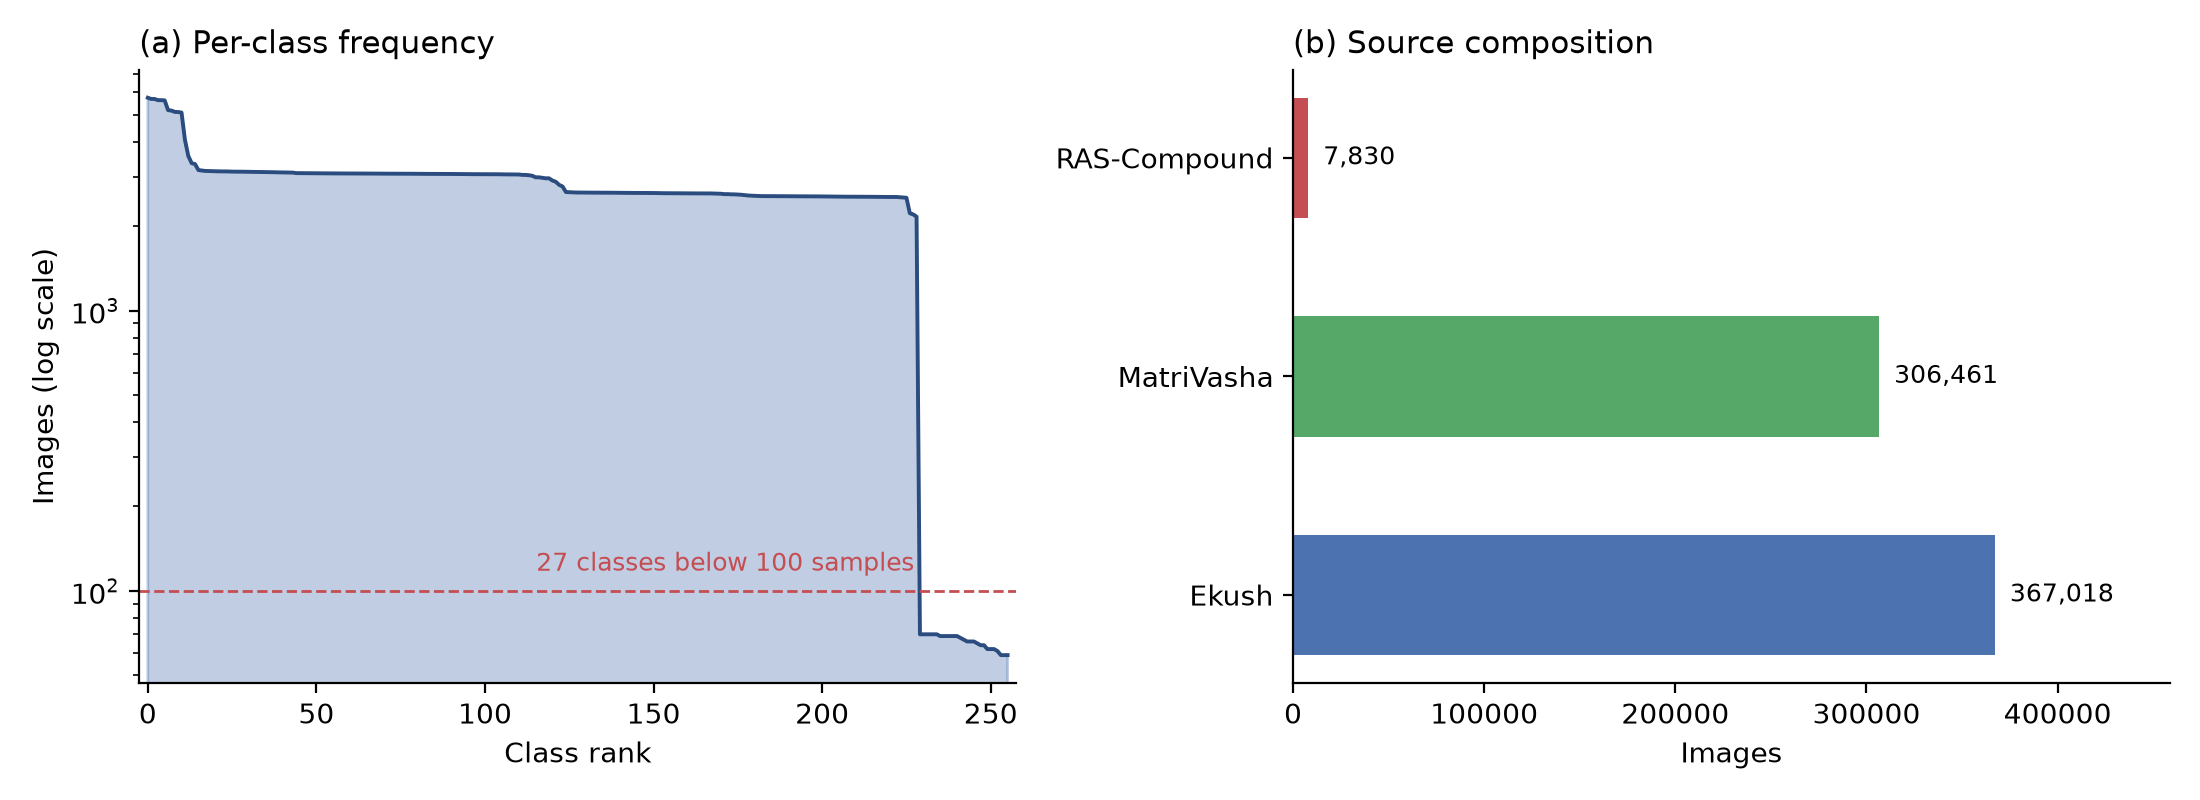

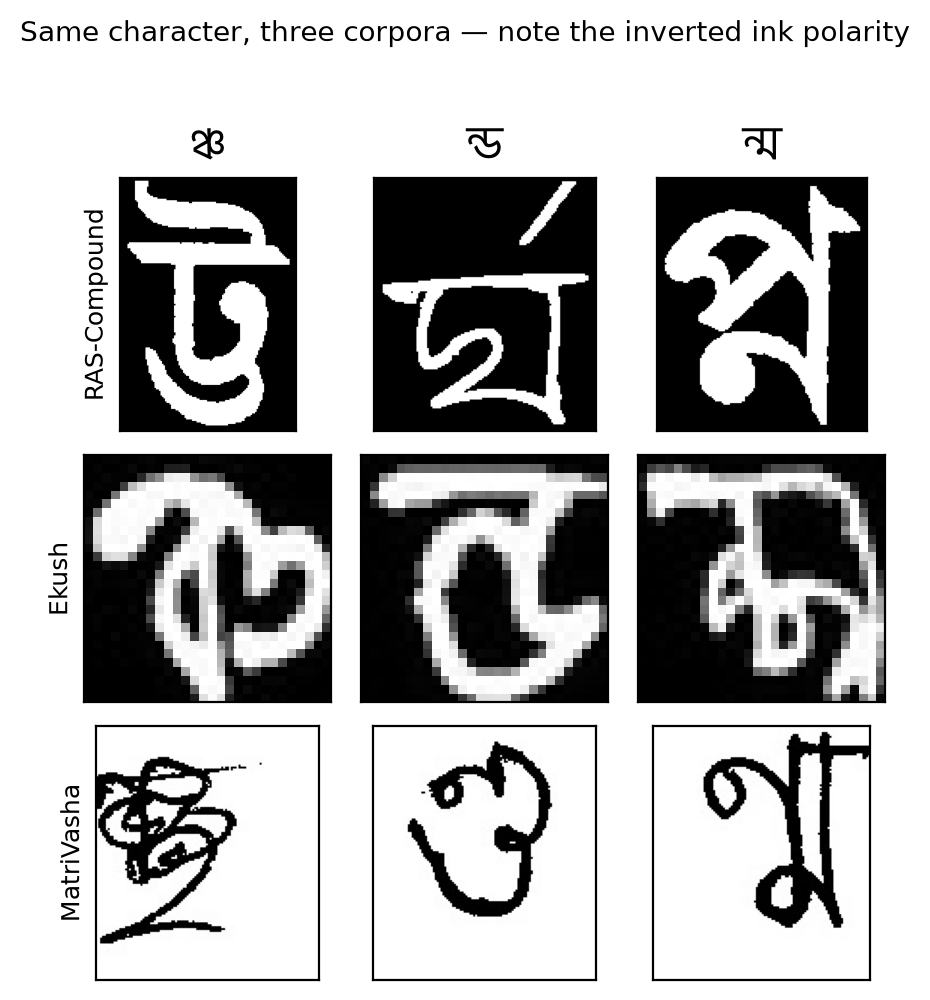

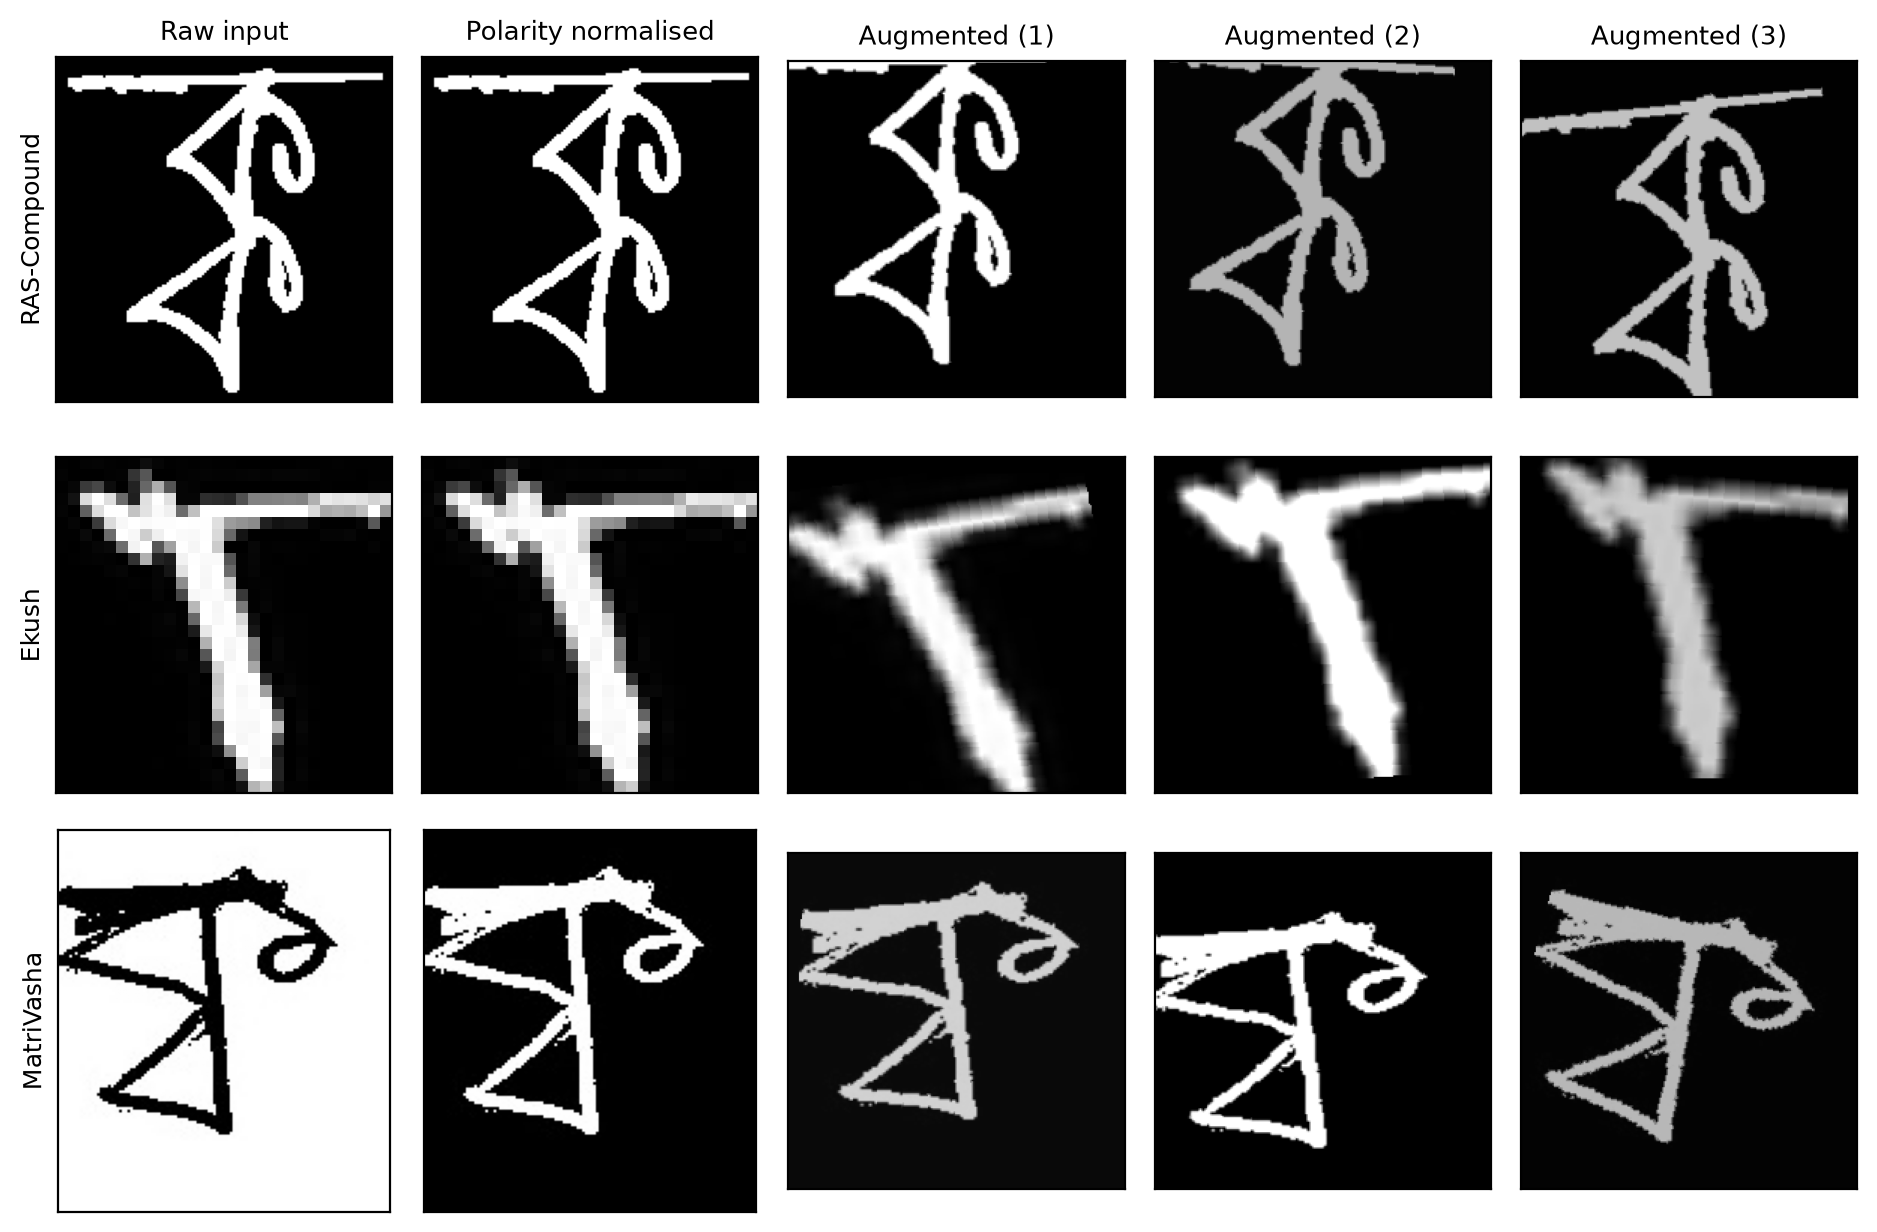

In [8]:
from IPython.display import Image, display
for f in ('fig2_dataset', 'fig4_samples', 'fig5_preprocessing'):
    display(Image(f'../paper/{f}.png'))